In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [3]:
file_name = "hcm_aqi_full_dataset.csv"
folder_path = "dataset"
file_path = os.path.join(folder_path, file_name)

df = pd.read_csv(file_path)

In [4]:
df.head(5)

,time,PM10,PM2.5,CO,NO2,O3,SO2,AQI,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
0,2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,133,0.0,23.5,65,0.0,11.3,9
1,2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,133,0.0,23.0,67,0.0,10.3,12
2,2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,132,0.0,22.5,70,0.0,7.9,360
3,2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,131,0.0,22.0,73,0.0,8.3,360
4,2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,129,0.0,21.9,72,0.0,7.9,357


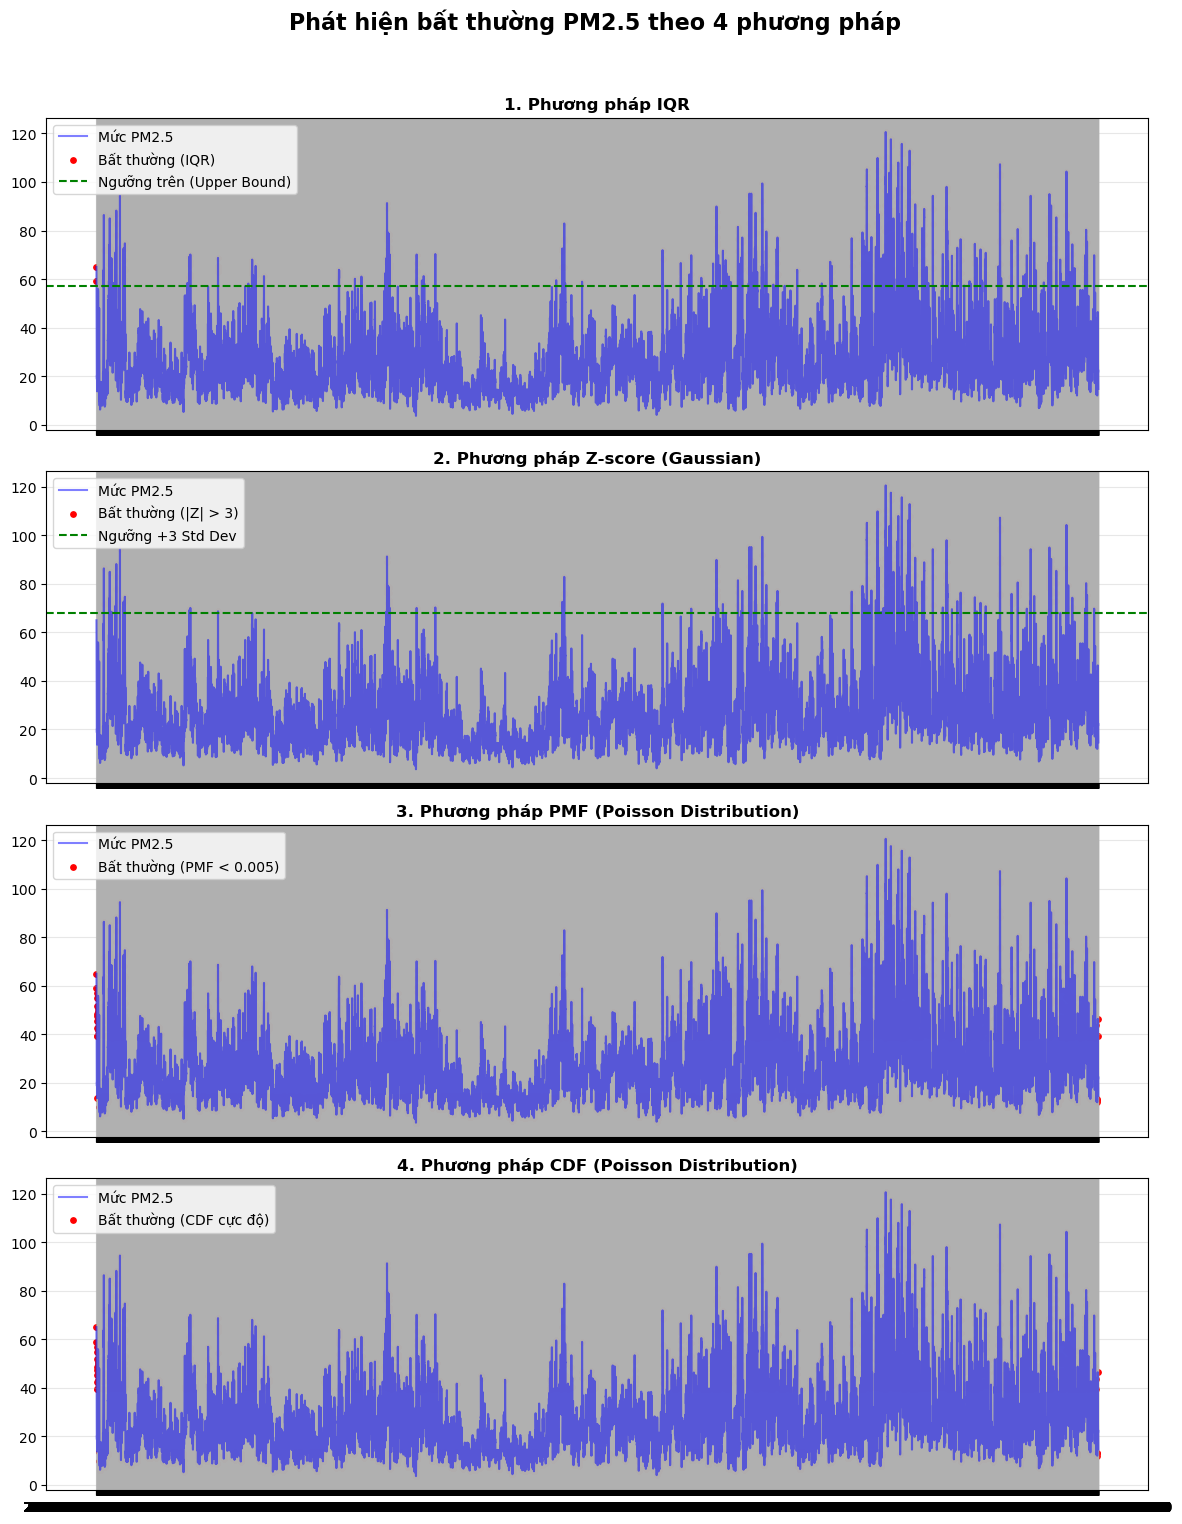

In [5]:
from scipy.stats import poisson, norm

# Tập trung vào dữ liệu PM2.5
times = df['time']
data = df['PM2.5'].values

# Lưu ý cho sinh viên AI: Phân phối Poisson dùng cho dữ liệu rời rạc (đếm số).
# Vì PM2.5 là số thực (continuous), ta cần làm tròn thành số nguyên để tính PMF và CDF.
data_int = np.round(data).astype(int)

# ==========================================
# PHƯƠNG PHÁP 1: IQR (Interquartile Range)
# ==========================================
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Đánh dấu bất thường nếu nằm ngoài [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
anomalies_iqr = (data < lower_bound) | (data > upper_bound)

# ==========================================
# PHƯƠNG PHÁP 2: Z-Score (Gaussian Distribution)
# ==========================================
mean = np.mean(data)
std = np.std(data)
z_scores = (data - mean) / std

# Ngưỡng (Threshold) phổ biến là 3 độ lệch chuẩn
anomalies_zscore = np.abs(z_scores) > 3

# ==========================================
# PHƯƠNG PHÁP 3: PMF (Poisson Distribution)
# ==========================================
# Tham số lambda (λ) của phân phối Poisson chính là giá trị trung bình
lam = np.mean(data_int)
pmf_values = poisson.pmf(data_int, lam)

# Nếu xác suất xảy ra của một giá trị PM2.5 rất thấp (vd < 0.5%), đó là bất thường
pmf_threshold = 0.005 
anomalies_pmf = pmf_values < pmf_threshold

# ==========================================
# PHƯƠNG PHÁP 4: CDF (Poisson Distribution)
# ==========================================
cdf_values = poisson.cdf(data_int, lam)

# Nếu giá trị nằm ở hai đuôi cực độ của phân phối (dưới 0.5% hoặc trên 99.5%)
anomalies_cdf = (cdf_values < 0.005) | (cdf_values > 0.995)

# ==========================================
# TRỰC QUAN HÓA (VẼ BIỂU ĐỒ)
# ==========================================
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
fig.suptitle('Phát hiện bất thường PM2.5 theo 4 phương pháp', fontsize=16, fontweight='bold')

# 1. Biểu đồ IQR
axes[0].plot(times, data, color='blue', alpha=0.5, label='Mức PM2.5')
axes[0].scatter(times[anomalies_iqr], data[anomalies_iqr], color='red', label='Bất thường (IQR)', s=15)
axes[0].axhline(upper_bound, color='green', linestyle='--', label='Ngưỡng trên (Upper Bound)')
axes[0].set_title('1. Phương pháp IQR', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Biểu đồ Z-Score
axes[1].plot(times, data, color='blue', alpha=0.5, label='Mức PM2.5')
axes[1].scatter(times[anomalies_zscore], data[anomalies_zscore], color='red', label='Bất thường (|Z| > 3)', s=15)
axes[1].axhline(mean + 3*std, color='green', linestyle='--', label='Ngưỡng +3 Std Dev')
axes[1].set_title('2. Phương pháp Z-score (Gaussian)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Biểu đồ PMF (Poisson)
axes[2].plot(times, data, color='blue', alpha=0.5, label='Mức PM2.5')
axes[2].scatter(times[anomalies_pmf], data[anomalies_pmf], color='red', label='Bất thường (PMF < 0.005)', s=15)
axes[2].set_title('3. Phương pháp PMF (Poisson Distribution)', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 4. Biểu đồ CDF (Poisson)
axes[3].plot(times, data, color='blue', alpha=0.5, label='Mức PM2.5')
axes[3].scatter(times[anomalies_cdf], data[anomalies_cdf], color='red', label='Bất thường (CDF cực độ)', s=15)
axes[3].set_title('4. Phương pháp CDF (Poisson Distribution)', fontweight='bold')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [ ]:
cols_to_log = ['PM10', 'PM2.5', 'CO', 'NO2', 'SO2', 'O3']

# 3. Vòng lặp lấy Log Transform cho từng cột
# Hàm np.log1p(x) tức là lấy log(x + 1), rất an toàn cho dữ liệu có chứa số 0
for col in cols_to_log:
    df[f'log_{col}'] = np.log1p(df[col])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.tight_layout(pad=5.0)

axes = axes.flatten()

for i, col in enumerate(cols_to_log):
    sns.histplot(df[f'log_{col}'], kde=True, ax=axes[i], color='skyblue', bins=30)
    
    axes[i].set_title(f'Phân phối của log_{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'log_{col}')
    axes[i].set_ylabel('Tần suất')

plt.show()


In [ ]:
import scipy.stats as stats

df['time'] = pd.to_datetime(df['time'])
df['Hour'] = df['time'].dt.hour

groups = [group['PM2.5'].values for name, group in df.groupby('Hour')]

f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Kết luận: Bác bỏ giả thuyết H0.")
    print("=> Có sự khác biệt ý nghĩa thống kê về nồng độ PM2.5 giữa các giờ trong ngày.")
else:
    print("Kết luận: Chấp nhận giả thuyết H0.")
    print("=> KHÔNG có sự khác biệt ý nghĩa thống kê về nồng độ PM2.5 giữa các giờ trong ngày.")

In [ ]:
corr_matrix = num_cols.corr(method='spearman')

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Ma trận tương quan ', fontsize=14, fontweight='bold')
plt.show()